# Notebook 14 – Classification Evaluation

**Big idea:** a classification model predicts a **category** (yes/no). Evaluation metrics tell us **what kind of mistakes it makes and how often**.

**Dataset:** `data.csv` – sales of an online gift shop (Dec 2010 – Dec 2011). Each row is one product line on a customer's bill (invoice). Invoice numbers starting with **"C"** are **cancelled** invoices.

**Our task:** predict whether an invoice is **cancelled (1)** or **normal (0)** from
1. `n_items` – number of product lines on the invoice
2. `total_qty` – total units on the invoice (absolute value, because cancellations have negative quantities)
3. `avg_price` – average unit price of the items

The class we want to find (**cancelled**) is called the **positive class**.

## Step 1 – Load and prepare the data

In [2]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score,
                             recall_score, f1_score, roc_curve, roc_auc_score,
                             precision_recall_curve, average_precision_score)
df = pd.read_csv("data.csv", encoding="ISO-8859-1", dtype={"InvoiceNo": str, "StockCode": str})
df = df[df.UnitPrice > 0].copy()
df["cancelled"] = df.InvoiceNo.str.startswith("C").astype(int)     
df["qty"] = df.Quantity.abs()
inv = df.groupby("InvoiceNo").agg(cancelled=("cancelled", "max"), n_items=("StockCode", "count"),
                                  total_qty=("qty", "sum"), avg_price=("UnitPrice", "mean"))
print(inv.cancelled.value_counts())
print(f"Only {inv.cancelled.mean():.1%} of invoices are cancelled")
inv.head()

cancelled
0    19960
1     3836
Name: count, dtype: int64
Only 16.1% of invoices are cancelled


,cancelled,n_items,total_qty,avg_price
InvoiceNo,,,,
536365,0,7,40,3.910000
536366,0,2,12,1.850000
536367,0,12,83,4.853333
536368,0,4,15,4.775000
536369,0,1,3,5.950000


## Step 2 – Train a simple model and predict

In [3]:
X = inv[["n_items", "total_qty", "avg_price"]]
y = inv["cancelled"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)).fit(X_train, y_train)
pred  = model.predict(X_test)                    
proba = model.predict_proba(X_test)[:, 1]        
print("Test invoices:", len(y_test), "| really cancelled:", y_test.sum())

Test invoices: 4760 | really cancelled: 767



## 1. Confusion Matrix (TP, TN, FP, FN)

**What is it?** A small table that compares **what really happened** with **what the model predicted**. It has four boxes, and every other metric is calculated from them.

| | Predicted **normal** (0) | Predicted **cancelled** (1) |
|---|:---:|:---:|
| **Really normal** (0) | **TN** – True Negative | **FP** – False Positive |
| **Really cancelled** (1) | **FN** – False Negative | **TP** – True Positive |

**How to read the names:** the 2nd word (Positive/Negative) is the model's *prediction*; the 1st word (True/False) says whether that prediction was *correct*.

| Term | Meaning in our shop |
|---|---|
| **True Positive (TP)** | Model said "cancelled" and it really was cancelled ✅ |
| **True Negative (TN)** | Model said "normal" and it really was normal ✅ |
| **False Positive (FP)** | Model said "cancelled" but the invoice was normal ❌ (false alarm) |
| **False Negative (FN)** | Model said "normal" but the invoice was cancelled ❌ (a miss) |

**Why use it?** It shows *which kind* of mistakes the model makes – a single number cannot.

TN=3697  FP=296  FN=342  TP=425


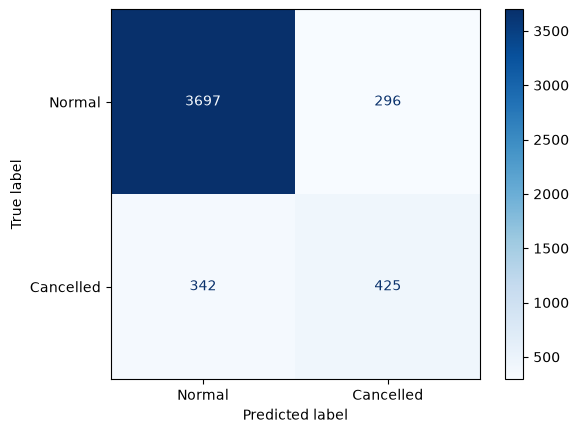

In [4]:
tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}")
ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=["Normal", "Cancelled"], cmap="Blues")
plt.grid(False); plt.show()

**Reading our result (4,760 test invoices):**
* **TP = 425** – cancelled invoices we caught
* **TN = 3,697** – normal invoices correctly left alone
* **FP = 296** – normal invoices wrongly flagged as cancelled
* **FN = 342** – cancelled invoices we missed


## 2. Accuracy – and why it is NOT enough

**What is it?** The share of **all** predictions that were correct.

Accuracy = (TP + TN) / (TP + TN + FP + FN)

**Example:** (425 + 3,697) / 4,760 = **0.866** → 86.6% correct.

**Why use it?** It is simple and everyone understands it. It works well when the classes are **balanced** and both kinds of mistakes cost about the same.

In [5]:
print("Accuracy:", round(accuracy_score(y_test, pred), 3))

Accuracy: 0.866


### Why accuracy alone is not sufficient
86.6% sounds good – but only **16%** of our invoices are cancelled. Let's compare with a "lazy model" that simply says **"normal" for every invoice** and never looks at the data:

In [6]:
lazy = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
lazy_pred = lazy.predict(X_test)
print(f"Lazy model  -> accuracy {accuracy_score(y_test, lazy_pred):.3f} | cancelled invoices found: {recall_score(y_test, lazy_pred):.0%}")
print(f"Our model   -> accuracy {accuracy_score(y_test, pred):.3f} | cancelled invoices found: {recall_score(y_test, pred):.0%}")

Lazy model  -> accuracy 0.839 | cancelled invoices found: 0%
Our model   -> accuracy 0.866 | cancelled invoices found: 55%


The lazy model gets **83.9% accuracy while finding 0 cancelled invoices** – it is completely useless. Our model is only about 3 points higher on accuracy, so accuracy hardly shows how much more useful it is.

**Reasons accuracy alone can mislead:**
1. **Imbalanced classes** – when one class is much bigger, guessing it gives a high score.
2. **It hides the type of mistake** – a miss (FN) and a false alarm (FP) both count as "one wrong answer", though they may cost very different amounts.
3. **It says nothing about the class we care about** – here, cancelled invoices.
4. **It changes with the threshold** – you'll see this in Section 7: making the model catch *more* cancellations makes accuracy go *down*.

So we also need **precision, recall, specificity and F1**.

---
## 3. Precision

**What is it?** Of all invoices the model **flagged as cancelled**, how many really were?

`Precision = TP / (TP + FP)`

**Example:** 425 / (425 + 296) = **0.589** → when the model says "cancelled", it is right about 59% of the time.

**Why use it?** When a **false alarm is costly** – e.g. if every flagged invoice needs an expensive manual check, or a spam filter that hides real emails.

In [9]:
print("Precision:", round(precision_score(y_test, pred), 3))

Precision: 0.589



## 4. Recall (Sensitivity)

**What is it?** Of all invoices that **really were cancelled**, how many did the model find?

`Recall = TP / (TP + FN)`

**Example:** 425 / (425 + 342) = **0.554** → the model finds about 55% of cancelled invoices and misses the other 45%.

**Why use it?** When a **miss is costly** – e.g. disease screening, fraud detection, or here, not noticing a cancelled order.

In [7]:
print("Recall:", round(recall_score(y_test, pred), 3))

Recall: 0.554


## 5. Specificity

**What is it?** Of all invoices that were **really normal**, how many did the model correctly leave alone? (Recall's mirror image, for the negative class.)

`Specificity = TN / (TN + FP)`

**Example:** 3,697 / (3,697 + 296) = **0.926** → about 93% of normal invoices are correctly cleared.

**Why use it?** To know how often the model raises **false alarms on normal cases**. It is standard in medical tests (*sensitivity* = recall, *specificity* as above). Note: `1 − specificity` is the **False Positive Rate**, used on the ROC curve.

In [11]:
print("Specificity:", round(tn / (tn + fp), 3))

Specificity: 0.926



## 6. F1 Score

**What is it?** One number that combines **precision and recall**. It is high only when *both* are high (it uses the "harmonic mean", which is pulled down by the weaker one).

`F1 = 2 × Precision × Recall / (Precision + Recall)`

**Example:** 2 × 0.589 × 0.554 / (0.589 + 0.554) = **0.571**.

**Why use it?** When classes are imbalanced and you want a single score that is not fooled by lots of easy negatives. It is more honest than accuracy for the positive class.

In [12]:
print("F1 score:", round(f1_score(y_test, pred), 3))

F1 score: 0.571



## 7. Threshold: the hidden setting behind all metrics

The model really outputs a **probability** of "cancelled". We turn it into a yes/no with a **threshold** (default **0.5**: probability ≥ 0.5 → "cancelled").

* **Lower threshold** → flag more invoices → **recall goes up**, precision goes down.
* **Higher threshold** → flag fewer → **precision goes up**, recall goes down.

So all the metrics above belong to *one* threshold. Let's try a lower one:

In [13]:
for t in [0.5, 0.3]:
    p = (proba >= t).astype(int)
    print(f"threshold {t}: accuracy={accuracy_score(y_test, p):.3f}  precision={precision_score(y_test, p):.3f}  "
          f"recall={recall_score(y_test, p):.3f}  F1={f1_score(y_test, p):.3f}")

threshold 0.5: accuracy=0.866  precision=0.589  recall=0.554  F1=0.571
threshold 0.3: accuracy=0.843  precision=0.508  recall=0.864  F1=0.640


With threshold **0.3**, recall jumps from **55% to 86%** (we find far more cancelled invoices), precision falls from 59% to 51%, F1 improves (0.57 → 0.64) – and **accuracy actually goes down** (86.6% → 84.3%).

This is the clearest example of why accuracy alone is not enough: **the model became more useful for our goal, but accuracy said it got worse.** Choosing the threshold is a business decision: which mistake costs more, a miss or a false alarm?


## 8. ROC Curve

**What is it?** A graph showing model performance at **every possible threshold**:
* **y-axis:** True Positive Rate (= recall)
* **x-axis:** False Positive Rate (= 1 − specificity)

Each point is a different threshold. **Curve close to the top-left corner = good.** The dashed diagonal = random guessing.

**Why use it?** It compares models **without picking a threshold first**, and shows the trade-off between catching positives and raising false alarms.

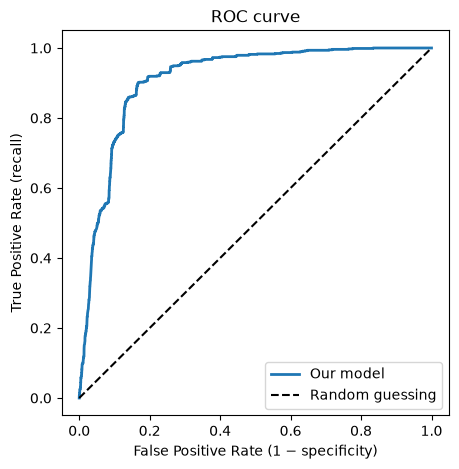

In [8]:
fpr, tpr, _ = roc_curve(y_test, proba)
plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, lw=2, label="Our model")
plt.plot([0, 1], [0, 1], "k--", label="Random guessing")
plt.xlabel("False Positive Rate (1 − specificity)"); plt.ylabel("True Positive Rate (recall)")
plt.title("ROC curve"); plt.legend(); plt.show()

## 9. AUC (Area Under the ROC Curve)

**What is it?** The ROC curve squeezed into **one number between 0 and 1**.

* **1.0** = perfect, **0.5** = random guessing.
* **Meaning:** if you pick one random cancelled invoice and one random normal invoice, AUC is the chance that the model gives the cancelled one the **higher** probability.

**Why use it?** A single, threshold-free score for comparing models. Rough guide: 0.9+ excellent, 0.8–0.9 good, 0.7–0.8 fair.

In [15]:
print("AUC:", round(roc_auc_score(y_test, proba), 3))

AUC: 0.912


AUC ≈ **0.91** – the model is very good at *ranking* cancelled invoices above normal ones, even though at threshold 0.5 its recall was only 55%. That tells us the model has real signal and a better threshold can unlock it (as we saw in Section 7).


## 10. Precision–Recall Curve

**What is it?** Like ROC, but plots **precision (y)** against **recall (x)** for every threshold. **Curve close to the top-right = good.**

The "no skill" baseline is a flat line at the **share of positives** (here 16%), not a diagonal.

**Why use it?** When the **positive class is rare**, it gives a more honest picture than ROC, because it ignores the huge number of easy true negatives. Its summary number is **Average Precision (AP)**.

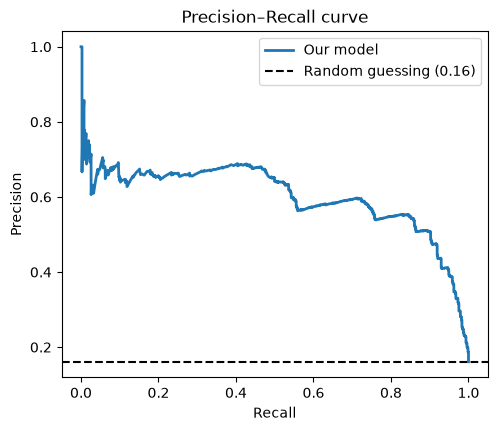

Average Precision: 0.602


In [9]:
prec, rec, _ = precision_recall_curve(y_test, proba)
base = y_test.mean()
plt.figure(figsize=(5.5, 4.5))
plt.plot(rec, prec, lw=2, label="Our model")
plt.axhline(base, color="k", linestyle="--", label=f"Random guessing ({base:.2f})")
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("Precision–Recall curve"); plt.legend(); plt.show()
print("Average Precision:", round(average_precision_score(y_test, proba), 3))